In [1]:
import numpy as np
import pandas as pd
import optuna, os
import mlflow
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

/home/mle-user/mle-final-project/.venv_final/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
access = os.getenv("AWS_ACCESS_KEY_ID")
secret = os.getenv("AWS_SECRET_ACCESS_KEY")
endpoint = os.getenv("S3_ENDPOINT_URL")
bucket = os.getenv("S3_BUCKET")

In [2]:
events = pd.read_csv("data/events.csv")

In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [ ]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")

In [ ]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [ ]:
popular_items = events.groupby("itemid").size().reset_index(name="count").sort_values(by="count", ascending=False)

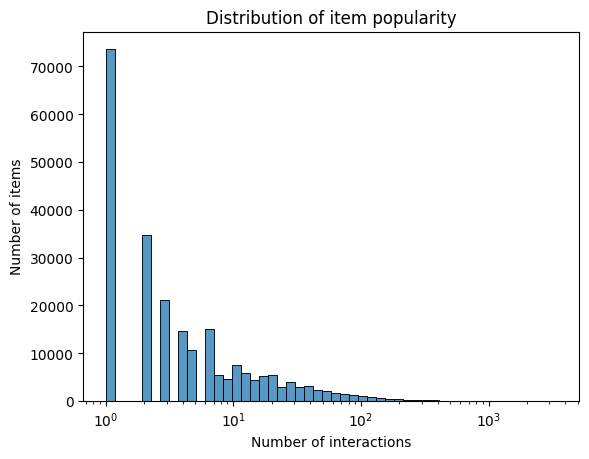

In [ ]:
sns.histplot(popular_items["count"], bins=50, log_scale=True)
plt.title("Distribution of item popularity")
plt.xlabel("Number of interactions")
plt.ylabel("Number of items")
plt.show()

Наблюдается, что большинство объектов было просмотрено однократно

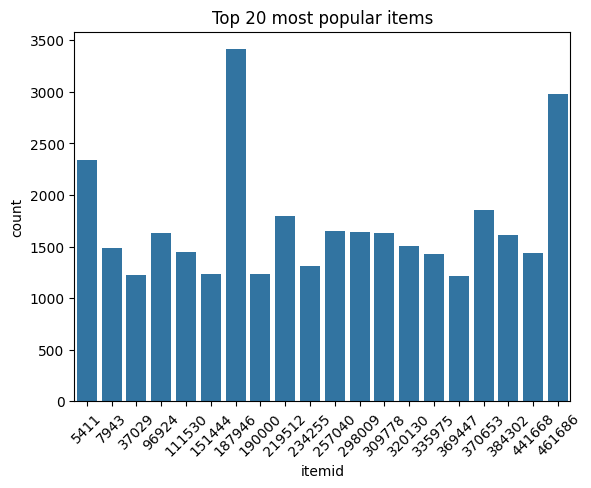

In [ ]:
sns.barplot(x="itemid", y="count", data=popular_items.head(20))
plt.title("Top 20 most popular items")
plt.xticks(rotation=45)
plt.show()

In [ ]:
events["timestamp"].min(), events["timestamp"].max()

(Timestamp('2015-05-03 03:00:04.384000'),
 Timestamp('2015-09-18 02:59:47.788000'))

In [ ]:
split_point = pd.to_datetime("2015-09-01")
split_idx = events["timestamp"] > split_point

In [ ]:
events_train = events[~split_idx]
events_test = events[split_idx]

In [ ]:
len(events_train), len(events_test)

(2452391, 303710)

In [ ]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

In [ ]:
user_encoder.fit(events_train["visitorid"])

LabelEncoder()

In [ ]:
events_train["visitorid_enc"] = user_encoder.transform(events_train["visitorid"])

/tmp/ipykernel_2676/1842400670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["visitorid_enc"] = user_encoder.transform(events_train["visitorid"])


In [ ]:
item_encoder.fit(events_train["itemid"])

LabelEncoder()

In [ ]:
events_train["itemid_enc"] = item_encoder.transform(events_train["itemid"])

/tmp/ipykernel_2676/4028693890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["itemid_enc"] = item_encoder.transform(events_train["itemid"])


In [ ]:
weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 3
}

In [ ]:
events_train["event"] = events_train["event"].map(weights)

/tmp/ipykernel_2676/4039242904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["event"] = events_train["event"].map(weights)


In [ ]:
train_dataset = events_train.groupby(["visitorid_enc", "itemid_enc"])["event"].sum().reset_index()

In [ ]:
items_to_csx = train_dataset["itemid_enc"]
users_to_csx = train_dataset["visitorid_enc"]

In [ ]:
len(items_to_csx), len(users_to_csx)

(1905695, 1905695)

In [ ]:
user_item_csx_matrix = csr_matrix((train_dataset["event"], (users_to_csx, items_to_csx)))

In [ ]:
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.05,
    iterations=10,
    alpha=40,
    random_state=42
)

/home/mle-user/mle-final-project/.venv_final/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [ ]:
als_model.fit(user_item_csx_matrix)

100%|██████████| 10/10 [00:35<00:00,  3.54s/it]


In [ ]:
def get_als_recommendations(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    user_id_enc = user_encoder.transform(user_id)[0]
    recommendations = model.recommend(user_id_enc,
                                      user_item_matrix[user_id_enc],
                                      filter_already_liked_items=include_seen,
                                      N=n)
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations['item_id'] = item_encoder.inverse_transform(recommendations["item_id_enc"])

    return recommendations

In [ ]:
events_test = events_test[events_test["visitorid"].isin(user_encoder.classes_) & events_test["itemid"].isin(item_encoder.classes_)].copy()

In [ ]:
users_with_more_interactions = events_test.groupby("visitorid").size()[events_test.groupby("visitorid").size() > 1].reset_index(name="act_num")

In [ ]:
events_with_more_interactions = events_test[events_test["visitorid"].isin(users_with_more_interactions["visitorid"])]

In [ ]:
sample_user = events_with_more_interactions.sample()

In [ ]:
relevant_items = events_with_more_interactions[events_with_more_interactions["visitorid"] == sample_user["visitorid"].iloc[0]]["itemid"].tolist()

In [ ]:
def objective(trial: optuna.Trial):
    alpha = trial.suggest_int('alpha', 10, 50, 10)
    factors = trial.suggest_int('factors', 20, 100, 10)
    regularization = trial.suggest_float('regularization', 1e-2, 1e-1)


    als_model = AlternatingLeastSquares(
    factors=factors,
    regularization=regularization,
    alpha=alpha,
    iterations=10,
    random_state=42
)
    als_model.fit(user_item_csx_matrix)
    recommendations = get_als_recommendations(user_item_csx_matrix, als_model, sample_user["visitorid"], user_encoder, item_encoder, False, 15)
    recall = len(set(relevant_items) & set(recommendations["item_id"].tolist())) / len(relevant_items)

    return recall


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-20 03:01:29,938] A new study created in memory with name: no-name-b6fde396-66d8-46e0-b2fb-dfdcb4b6e119
/tmp/ipykernel_1654/1913730152.py:2: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  alpha = trial.suggest_int('alpha', 10, 50, 10)
/tmp/ipykernel_1654/1913730152.py:3: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please 

In [ ]:
study.best_params, study.best_value

({'alpha': 30, 'factors': 80, 'regularization': 0.09322209365648951},
 0.0020242914979757085)

In [ ]:
best_parms = study.best_params

In [ ]:
als_final_modal = AlternatingLeastSquares(iterations=10, random_state=42, **best_parms)

/home/mle-user/mle-final-project/.venv_final/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [ ]:
als_final_modal.fit(user_item_csx_matrix)

100%|██████████| 10/10 [00:45<00:00,  4.59s/it]


In [ ]:
als_final_recommendations = get_als_recommendations(user_item_csx_matrix, als_final_modal, sample_user["visitorid"], user_encoder, item_encoder, False, 15)

In [ ]:
als_recall_score = len(set(als_final_recommendations["item_id"].tolist()) & set(relevant_items)) / len(relevant_items)
als_precision_score = len(set(als_final_recommendations["item_id"].tolist()) & set(relevant_items)) / len(als_final_recommendations["item_id"].tolist())

In [ ]:
sample_item_enc = item_encoder.transform(sample_user["itemid"])[0]

In [ ]:
similar_items = als_final_modal.similar_items(sample_item_enc)

In [ ]:
similar_items = pd.DataFrame({"item_id_enc": similar_items[0].ravel(), "score": similar_items[1].ravel()})[1:]
similar_items["item_id"] = item_encoder.inverse_transform(similar_items["item_id_enc"])

In [ ]:
intersection = set(similar_items["item_id"].tolist()) & set(relevant_items)

In [ ]:
metrics = {}
metrics["recall_score"] = als_recall_score
metrics["precision_score"] = als_precision_score

In [ ]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")

In [3]:
EXPERIMENT_NAME = "Training_RECSYS_model"
REGISTRY_MODEL_NAME = "Recsys_model"
RUN_NAME = "als_model"

In [ ]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

In [ ]:
from pathlib import Path
import pickle
from helper_fun import AlsModel
import scipy.sparse as sp
import tempfile

In [ ]:
cumtom_model = AlsModel(als_final_modal)

In [5]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.environ.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ.get("AWS_SECRET_ACCESS_KEY")

In [ ]:
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)

        run_id = run.info.run_id

        with open(tmp / "als_model.pkl", "wb") as f:
            pickle.dump(als_final_modal, f)
        
        with open(tmp / "user_encoder.pkl", "wb") as f:
            pickle.dump(user_encoder, f)
        
        with open(tmp / "item_encoder.pkl", "wb") as f:
            pickle.dump(item_encoder, f)
        
        sp.save_npz(tmp / "user_items_matrix.npz", user_item_csx_matrix)
        popular_items.to_parquet(tmp / "popular_items.parquet", index=False)
        
        mlflow.pyfunc.log_model(python_model=cumtom_model, 
                                artifact_path="models", 
                                registered_model_name=REGISTRY_MODEL_NAME,
                                artifacts={
                                    "als_model": str(tmp / "als_model.pkl"),
                                    "user_encoder": str(tmp / "user_encoder.pkl"),
                                    "item_encoder": str(tmp / "item_encoder.pkl"),
                                    "user_items_matrix": str(tmp / "user_items_matrix.npz"),
                                    "popular_items": str(tmp / "popular_items.parquet"),
                                },
                                pip_requirements=[
                                    "mlflow",
                                    "pandas",
                                    "scipy",
                                    "implicit",
                                    "pyarrow",
                                    "scikit-learn"
                                ])

        print("Run ID: ", run_id)

2026/04/21 05:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 05:34:04 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/04/21 05:34:04 WARNING mlflow.pyfunc: Failed to infer model signature: Type hint <input: <class 'pandas.core.frame.DataFrame'>, output: None> cannot be used to infer model signature and input example is not provided, model signature cannot be inferred.
Registered model 'Recsys_model' already exists. Creating a new version of this model...
2026/04/21 05:34:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Recsys_model, version 3

Run ID:  334d3cda494d46339a06c1270ba87ad1
🏃 View run als_model at: http://127.0.0.1:5000/#/experiments/15/runs/334d3cda494d46339a06c1270ba87ad1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/15
